# Dự án 3: Phân tích hiệu quả tài chính phim

## Mục tiêu
Bộ dữ liệu hiện có chỉ gồm `budget` và `revenue`, nhưng vẫn đủ để tạo một mini-project
về hiệu quả tài chính:

1. Phim có ngân sách cao có luôn tạo ra doanh thu cao hơn không?
2. Tỷ lệ sinh lời (ROI) phân bố ra sao?
3. Nhóm ngân sách nào có xác suất sinh lời tốt nhất?

## Giới hạn dữ liệu
- Chưa có tên phim, thể loại, ngày phát hành.
- Vì vậy notebook này tập trung vào **phân tích tài chính định lượng**, chưa đi vào storytelling theo từng phim cụ thể.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 6)

DATA_DIR = Path('data')
movies = pd.read_csv(DATA_DIR / 'financials.csv')
movies = movies.drop(columns=[col for col in movies.columns if col.startswith('Unnamed')], errors='ignore')
movies['profit'] = movies['revenue'] - movies['budget']
movies['roi'] = movies['profit'] / movies['budget']

print('Kích thước dữ liệu:', movies.shape)
movies.head()

Kích thước dữ liệu: (3229, 5)


,id,budget,revenue,profit,roi
0,19995,237000000,2.787965e+09,2.550965e+09,10.763566
1,285,300000000,9.610000e+08,6.610000e+08,2.203333
2,206647,245000000,8.806746e+08,6.356746e+08,2.594590
3,49026,250000000,1.084939e+09,8.349391e+08,3.339756
4,49529,260000000,2.841391e+08,2.413910e+07,0.092843


## 1. Thống kê tổng quan

In [2]:
summary = pd.DataFrame({
    'metric': ['so_phim', 'budget_trung_vi', 'revenue_trung_vi', 'profit_share'],
    'value': [
        len(movies),
        movies['budget'].median(),
        movies['revenue'].median(),
        (movies['profit'] > 0).mean()
    ]
})
display(summary)
display(movies[['budget', 'revenue', 'profit', 'roi']].describe().T)

,metric,value
0,so_phim,3.229000e+03
1,budget_trung_vi,2.500000e+07
2,revenue_trung_vi,5.518472e+07
3,profit_share,7.550325e-01


,count,mean,std,min,25%,50%,75%,max
budget,3229.0,4.065444e+07,4.439674e+07,1.000000e+00,1.050000e+07,2.500000e+07,5.500000e+07,3.800000e+08
revenue,3229.0,1.212430e+08,1.863029e+08,5.000000e+00,1.700000e+07,5.518472e+07,1.462920e+08,2.787965e+09
profit,3229.0,8.058851e+07,1.581479e+08,-1.657101e+08,2.113940e+05,2.616557e+07,9.748982e+07,2.550965e+09
roi,3229.0,2.953822e+03,1.506101e+05,-9.999995e-01,2.246328e-02,1.300366e+00,3.420822e+00,8.499999e+06


## 2. Quan hệ giữa ngân sách và doanh thu

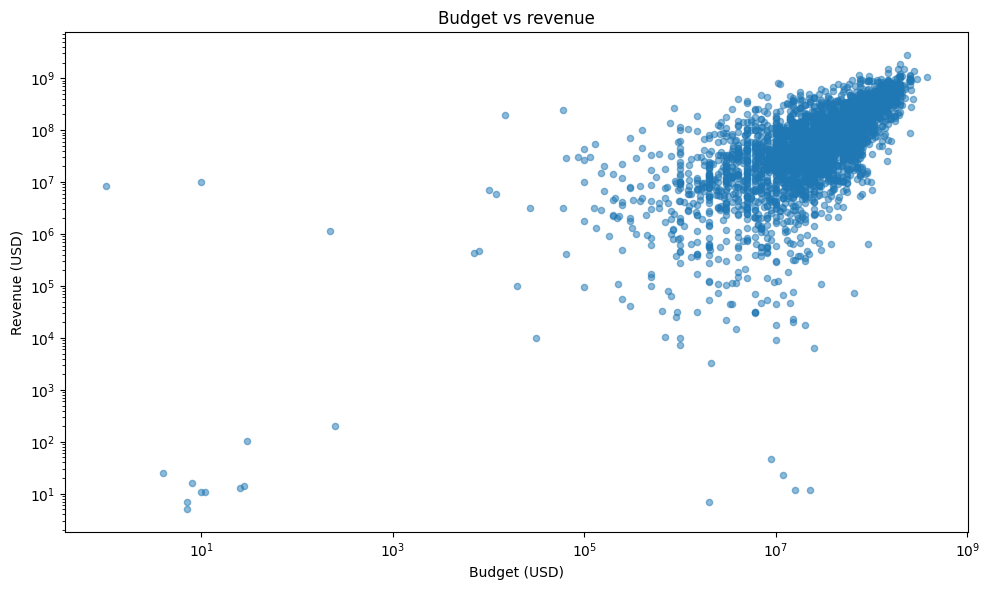

Tương quan budget - revenue: 0.705


In [3]:
ax = movies.plot(kind='scatter', x='budget', y='revenue', alpha=0.5)
ax.set_title('Budget vs revenue')
ax.set_xlabel('Budget (USD)')
ax.set_ylabel('Revenue (USD)')
ax.set_xscale('log')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

print('Tương quan budget - revenue:', round(movies['budget'].corr(movies['revenue']), 3))

## 3. ROI và mức độ sinh lời

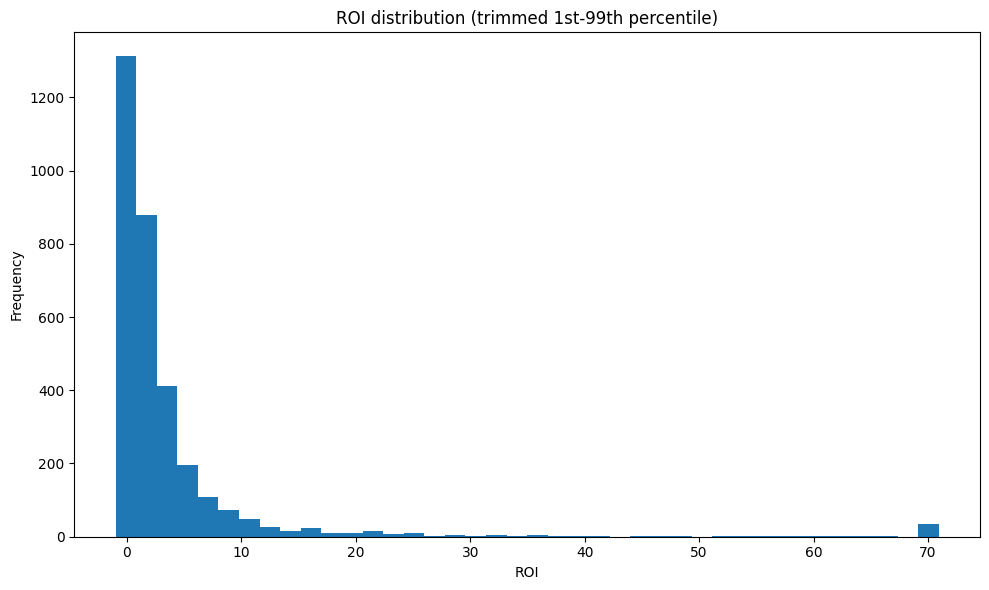

In [4]:
roi_trim = movies['roi'].clip(lower=movies['roi'].quantile(0.01), upper=movies['roi'].quantile(0.99))
ax = roi_trim.plot(kind='hist', bins=40)
ax.set_title('ROI distribution (trimmed 1st-99th percentile)')
ax.set_xlabel('ROI')
plt.tight_layout()
plt.show()

## 4. So sánh theo nhóm ngân sách

Chia phim thành 4 nhóm ngân sách để xem nhóm nào có trung vị doanh thu, trung vị lợi nhuận
và tỷ lệ phim có lãi tốt hơn.

In [5]:
bins = [0, 10_000_000, 50_000_000, 100_000_000, 10_000_000_000]
labels = ['<10M', '$10M-$50M', '$50M-$100M', '>=$100M']
movies['budget_band'] = pd.cut(movies['budget'], bins=bins, labels=labels, include_lowest=True)

band_summary = (
    movies.groupby('budget_band', observed=False)
          .agg(
              so_phim=('id', 'count'),
              budget_trung_vi=('budget', 'median'),
              revenue_trung_vi=('revenue', 'median'),
              profit_trung_vi=('profit', 'median'),
              roi_trung_vi=('roi', 'median'),
              ty_le_co_lai=('profit', lambda s: (s > 0).mean())
          )
          .reset_index()
)
display(band_summary)

,budget_band,so_phim,budget_trung_vi,revenue_trung_vi,profit_trung_vi,roi_trung_vi,ty_le_co_lai
0,<10M,805,4000000.0,11098131.0,7500000.0,2.435523,0.751553
1,$10M-$50M,1567,25000000.0,51801187.0,25419521.0,1.085514,0.723038
2,$50M-$100M,579,70000000.0,142044638.0,70432927.0,0.990156,0.766839
3,>=$100M,278,150000000.0,393840596.0,244649639.0,1.760223,0.920863


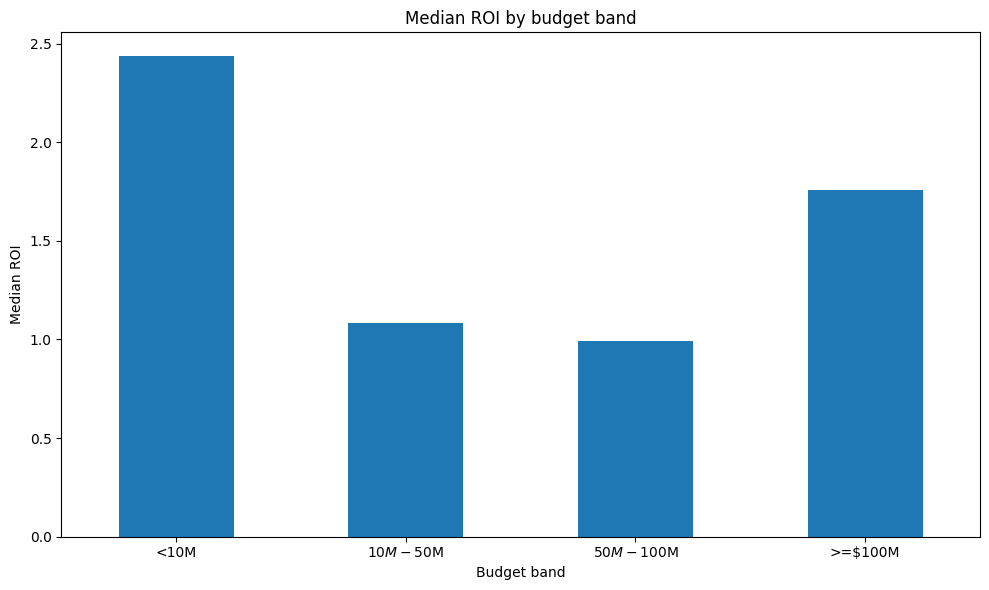

In [6]:
ax = band_summary.plot(kind='bar', x='budget_band', y='roi_trung_vi', legend=False)
ax.set_title('Median ROI by budget band')
ax.set_xlabel('Budget band')
ax.set_ylabel('Median ROI')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

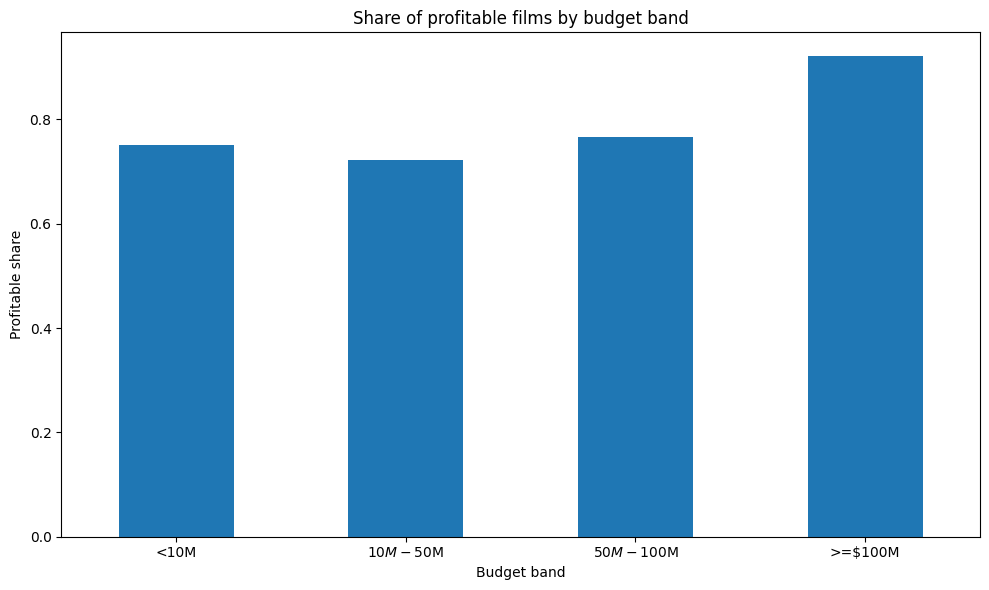

In [7]:
ax = band_summary.plot(kind='bar', x='budget_band', y='ty_le_co_lai', legend=False)
ax.set_title('Share of profitable films by budget band')
ax.set_xlabel('Budget band')
ax.set_ylabel('Profitable share')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Kết luận ngắn

In [8]:
top_roi = movies[movies['budget'] >= 1_000_000].nlargest(10, 'roi')[['id', 'budget', 'revenue', 'profit', 'roi']]
display(top_roi)

print('Nhận xét:')
print('- Budget và revenue có tương quan dương khá rõ, nghĩa là phim ngân sách cao thường tạo doanh thu cao hơn.')
print('- Tuy vậy, ROI không tăng tuyến tính theo budget. Nhiều phim vốn vừa hoặc thấp vẫn có ROI rất mạnh.')
print('- Nhóm >=$100M có tỷ lệ phim có lãi cao nhất trong bộ dữ liệu này, nhưng nhóm <10M lại có ROI trung vị rất tốt.')
print('- Vì thiếu metadata phim, bước tiếp theo nên là bổ sung title/genre/release_date để kể chuyện tốt hơn trong portfolio.')

,id,budget,revenue,profit,roi
3082,408,1488423,184925486.0,183437063.0,123.242561
3105,1366,1000000,117235147.0,116235147.0,116.235147
3117,76487,1000000,101758490.0,100758490.0,100.758490
2880,770,4000000,400176459.0,396176459.0,99.044115
3092,176,1200000,103911669.0,102711669.0,85.593058
2426,601,10500000,792910554.0,782410554.0,74.515291
2778,8346,5000000,368744044.0,363744044.0,72.748809
2888,9427,3500000,257850122.0,254350122.0,72.671463
2388,11,11000000,775398007.0,764398007.0,69.490728
2325,578,7000000,470654000.0,463654000.0,66.236286


Nhận xét:
- Budget và revenue có tương quan dương khá rõ, nghĩa là phim ngân sách cao thường tạo doanh thu cao hơn.
- Tuy vậy, ROI không tăng tuyến tính theo budget. Nhiều phim vốn vừa hoặc thấp vẫn có ROI rất mạnh.
- Nhóm >=$100M có tỷ lệ phim có lãi cao nhất trong bộ dữ liệu này, nhưng nhóm <10M lại có ROI trung vị rất tốt.
- Vì thiếu metadata phim, bước tiếp theo nên là bổ sung title/genre/release_date để kể chuyện tốt hơn trong portfolio.
